## **Quantum Circuit Draw**

In [98]:
from qiskit import QuantumCircuit
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.circuit import QuantumCircuit, ParameterVector
from qiskit import  QuantumRegister, ClassicalRegister
import numpy as np
import matplotlib.pylab as plt

[CircuitInstruction(operation=Instruction(name='measure', num_qubits=1, num_clbits=1, params=[]), qubits=(<Qubit register=(2, "q"), index=0>,), clbits=(<Clbit register=(2, "c"), index=1>,))]


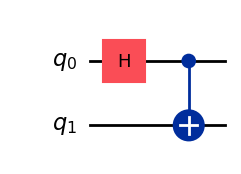

In [99]:
qc = QuantumCircuit(2, 2)
qc.measure([0], [1])
print(qc.data)

# Create a new circuit with two qubits
qc = QuantumCircuit(2)

# Add a Hadamard gate to qubit 0
qc.h(0)

#controlled-X gate on qubit 1
qc.cx(0, 1)

# Return a text drawing of the circuit.
qc.draw('mpl')

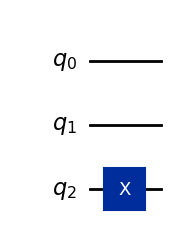

In [100]:
n=2
c_o = QuantumCircuit(n+1)
out_put = np.random.randint(1)
if out_put == 0:
    c_o.x(n)
c_o.draw('mpl')

Original circuit:
        ┌───┐      ░ ┌─┐   
   q_0: ┤ H ├──■───░─┤M├───
        └───┘┌─┴─┐ ░ └╥┘┌─┐
   q_1: ─────┤ X ├─░──╫─┤M├
             └───┘ ░  ║ └╥┘
meas: 2/══════════════╩══╩═
                      0  1 


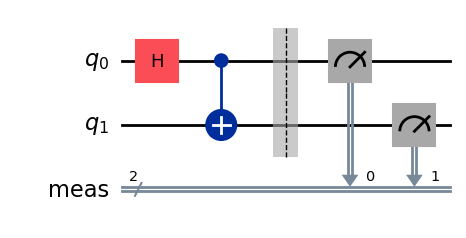

In [101]:
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.measure_all()

# Print the original circuit
print("Original circuit:")
print(qc)
qc.draw('mpl')



Transpiled circuit with basis gates ['u1', 'u2', 'u3', 'cx']:
            ┌─────────┐          ░ ┌─────────────────┐┌─┐
q_0 -> 0 ───┤ U2(0,π) ├──────■───░─┤ Delay(2034[dt]) ├┤M├
         ┌──┴─────────┴───┐┌─┴─┐ ░ └───────┬─┬───────┘└╥┘
q_1 -> 1 ┤ Delay(160[dt]) ├┤ X ├─░─────────┤M├─────────╫─
         └────────────────┘└───┘ ░         └╥┘         ║ 
 meas: 2/═══════════════════════════════════╩══════════╩═
                                            1          0 


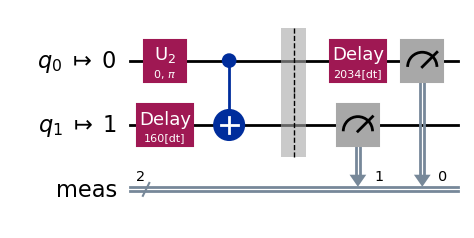

In [102]:
# Transpile the circuit with a specific basis gates list and print the resulting circuit
backend = GenericBackendV2(2, basis_gates=['u1', 'u2', 'u3', 'cx'])
pm = generate_preset_pass_manager(optimization_level=1, backend=backend, scheduling_method="alap")
transpiled_qc = pm.run(qc)
print("Transpiled circuit with basis gates ['u1', 'u2', 'u3', 'cx']:")
print(transpiled_qc)
transpiled_qc.draw('mpl')


In [103]:
# Print the start times of each instruction in the transpiled circuit
print("Start times of instructions in the transpiled circuit:")
for instruction, start_time in zip(transpiled_qc.data, transpiled_qc.op_start_times):
    print(f"{instruction.operation.name}: {start_time}")

Start times of instructions in the transpiled circuit:
u2: 0
delay: 0
cx: 160
barrier: 3168
delay: 3168
measure: 5202
measure: 3168


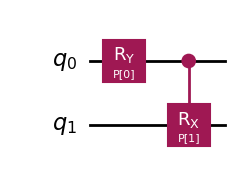

In [104]:
circuit = QuantumCircuit(2)
params = ParameterVector('P', 2)
circuit.ry(params[0], 0)
circuit.crx(params[1], 0, 1)

bound_circuit = circuit.assign_parameters([1, 2])
bound_circuit.draw('mpl')

circuit.draw('mpl')

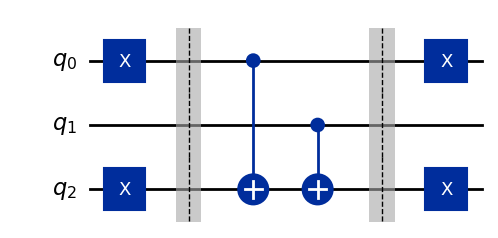

In [105]:
n=2
b_o = QuantumCircuit(n+1)
b_str ="101"

# Place X-gates
for qubit in range(len(b_str)):
    if b_str[qubit] =='1':
        b_o.x(qubit)

b_o.barrier()

# Controlled-NOT gates
for qubit in range(n):
    b_o.cx(qubit, n)
b_o.barrier()

# Place X-gates
for qubit in range(len(b_str)):
    if b_str[qubit] =='1':
        b_o.x(qubit)

b_o.draw('mpl')

## **Deutsch Algorithm**

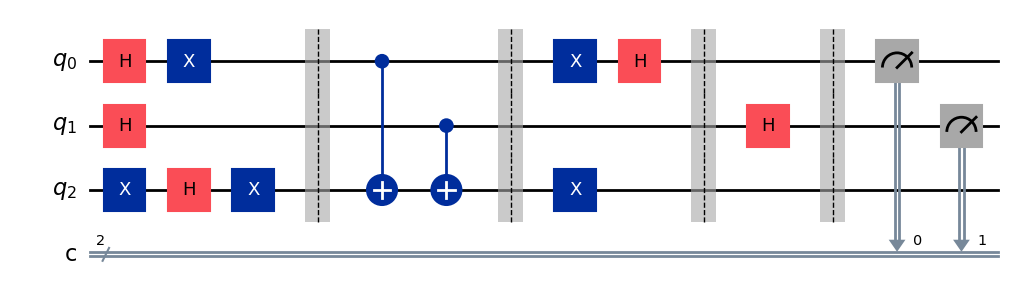

In [106]:
n=2
deustch_circuit = QuantumCircuit(n+1, n)
# Apply H-gates
for qubit in range(n):
    deustch_circuit.h(qubit)

deustch_circuit.x(n)
deustch_circuit.h(n)

deustch_circuit = deustch_circuit & (b_o)

for qubit in range(n):
    deustch_circuit.h(qubit)
    deustch_circuit.barrier()
# Measurement of states
for i in range(n):
    deustch_circuit.measure(i, i)
# To display deustch_circuit
deustch_circuit.draw('mpl')

## **Append Two Qcircuits**

Circuit combined with '&' operator:
      ┌───┐     ┌─┐┌───┐   ┌─┐
q1_0: ┤ H ├──■──┤M├┤ X ├───┤M├
      └───┘┌─┴─┐└╥┘└┬─┬┘┌─┐└╥┘
q1_1: ─────┤ X ├─╫──┤M├─┤M├─╫─
           └───┘ ║  └╥┘ └╥┘ ║ 
c1: 2/═══════════╩═══╩═══╩══╩═
                 0   1   1  0 


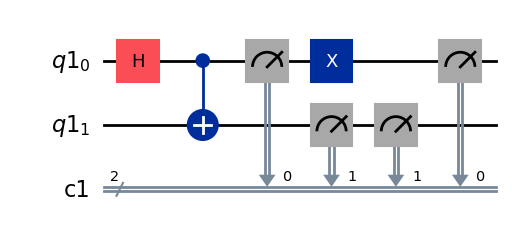

In [107]:

# Create the first circuit (2 qubits)
qr1 = QuantumRegister(2, name='q1')
cr1 = ClassicalRegister(2, name='c1')
qc1 = QuantumCircuit(qr1, cr1)
qc1.h(qr1[0]) # Add Hadamard to the first qubit of qc1
qc1.cx(qr1[0], qr1[1]) # Add CNOT gate
qc1.measure(qr1, cr1)

# Create the second circuit (2 qubits)
qr2 = QuantumRegister(2, name='q2')
cr2 = ClassicalRegister(2, name='c2')
qc2 = QuantumCircuit(qr2, cr2)
qc2.x(qr2[0]) # Add X gate to the first qubit of qc2
qc2.measure(qr2, cr2)

# Using the '&' operator (concatenation) ---
qc_combined_ampersand = qc1 & qc2
print("Circuit combined with '&' operator:")
print(qc_combined_ampersand.draw(output='text'))
qc_combined_ampersand.draw('mpl')




Circuit combined with compose() method (mapped):
      ┌───┐     ┌─┐        ┌─┐   
q1_0: ┤ H ├──■──┤M├────────┤M├───
      └───┘┌─┴─┐└╥┘┌─┐┌───┐└╥┘┌─┐
q1_1: ─────┤ X ├─╫─┤M├┤ X ├─╫─┤M├
           └───┘ ║ └╥┘└───┘ ║ └╥┘
c1: 2/═══════════╩══╩═══════╩══╩═
                 0  1       1  0 


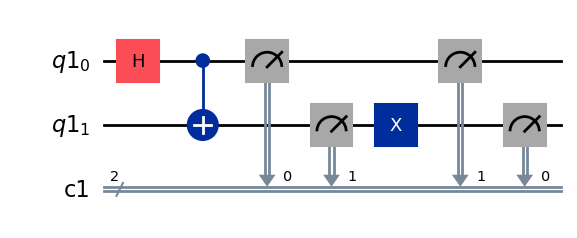

In [108]:
qc_combined_compose = qc1.compose(qc2, qubits=[1, 0], inplace=False)
print("\nCircuit combined with compose() method (mapped):")
print(qc_combined_compose.draw(output='text'))
qc_combined_compose.draw('mpl')